## 11. Walmart-ის გაყიდვების პროგნოზირება — DLinear

| Field | Details |
|---|---|
| **მოდელი** | DLinear (Decomposition Linear) |
| **კატეგორია** | Deep Learning — მარტივი წრფივი დეკომპოზიცია |
| **ბიბლიოთეკა** | `neuralforecast` (Nixtla) |
| **Logging** | WandB · project: `walmart-forecasting` |

> 🖥️ **Runtime → Change runtime type → T4 GPU** (mini-batch წვრთნისას GPU სჭირდება)

---

### Runs

| Run | აღწერა |
|---|---|
| `DLinear_Baseline` | საბაზისო კონფიგურაცია — `moving_avg_window=25` |
| `DLinear_LongerWindow` | `moving_avg_window=51` (ერთი წელი) |
| `DLinear_Deeper` | `hidden_size=256` — მეტი ტევადობა |
| `DLinear_Final` | საუკეთესო კონფიგურაცია სრულ სასწავლო მონაცემებზე |

---

### მთავარი იდეა

წარდგენილია 2022 წელს ნაშრომში: *"Are Transformers Effective for Time Series Forecasting?"*

DLinear არის მარტივი feed-forward ქსელი, რომელიც სამ ნაბიჯად მუშაობს:

| ნაბიჯი | აღწერა |
|---|---|
| **Decomposition** | Time series იყოფა ტრენდად (moving average) და სეზონურობად (residual) |
| **Linear projection** | თითოეული ნაწილი ცალკე გადის წრფივ ფენაში |
| **Sum** | შედეგები იჯამება საბოლოო პროგნოზისთვის |

---

### შედარება სხვა მოდელებთან

| მოდელი | სირთულე | მიდგომა |
|---|---|---|
| **DLinear** | მარტივი | მხოლოდ წრფივი ფენები |
| N-BEATS | რთული | Feed-forward + residual basis expansion |
| PatchTST | რთული | Transformer + patching |

DLinear ამოწმებს ჰიპოთეზას: **ნამდვილად სჭირდება თუ არა მოდელს ზედმეტი კომპლექსურობა?** ნაშრომში ავტორები აჩვენებენ, რომ ეს ორი `Linear()` ფენა PyTorch-ში ბევრ transformer-based მოდელს აჯობებს სტანდარტულ benchmark datasets-ებზე.

---

### უპირატესობები

| უპირატესობა | დეტალი |
|---|---|
| **პრაქტიკულობა** | ყველა Store/Dept კომბინაციას ერთ გლობალურ მოდელში აჯგუფებს |
| **სიჩქარე** | PatchTST-ზე 3–4-ჯერ სწრაფად იწვრთნება |
| **სიმარტივე** | Attention და patch მექანიზმები არ სჭირდება |

## 1. Setup

In [ ]:
!pip install neuralforecast wandb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

import wandb
from pytorch_lightning.loggers import WandbLogger

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data: {DATA_DIR}")
print(f"Models: {MODELS_DIR}")

Mounted at /content/drive
Data: /content/drive/MyDrive/walmart/data
Models: /content/drive/MyDrive/walmart/models


In [ ]:
from google.colab import userdata

try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("WandB logged in")
except Exception as e:
    wandb.login()

WANDB_PROJECT = "walmart-forecasting"
print(f"WandB project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB logged in
WandB project: walmart-forecasting


## 2. მონაცემების მომზადება

DLinear იმავე long-format-ს იყენებს რასაც N-BEATS და PatchTST.

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")

Train: (421570, 5)
Test:  (115064, 4)


In [ ]:
def to_dlinear_format(df, has_target=True):
    df = df.copy()
    df['unique_id'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
    df = df.rename(columns={'Date': 'ds'})
    if has_target:
        df = df.rename(columns={'Weekly_Sales': 'y'})
        return df[['unique_id', 'ds', 'y']]
    return df[['unique_id', 'ds']]


train_dl = to_dlinear_format(train_raw, has_target=True)
test_dl = to_dlinear_format(test_raw, has_target=False)

# Filter short series
series_lengths = train_dl.groupby('unique_id').size()
MIN_LENGTH = 80
valid_ids = series_lengths[series_lengths >= MIN_LENGTH].index
train_dl = train_dl[train_dl['unique_id'].isin(valid_ids)].reset_index(drop=True)

print(f"Time series after filter (min length {MIN_LENGTH}): {train_dl['unique_id'].nunique()}")
print(f"Total rows: {len(train_dl)}")

Time series after filter (min length 80): 2934
Total rows: 412935


## 3. Train/Val Split + WMAE Metric

In [ ]:
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def evaluate_forecast(forecasts_df, val_df, train_raw_val, model_col='DLinear'):
    merged = forecasts_df.merge(val_df, on=['unique_id', 'ds'], how='inner')

    train_raw_val_lookup = train_raw_val.copy()
    train_raw_val_lookup['unique_id'] = (
        train_raw_val_lookup['Store'].astype(str) + '_' + train_raw_val_lookup['Dept'].astype(str)
    )
    train_raw_val_lookup = train_raw_val_lookup.rename(columns={'Date': 'ds'})

    merged = merged.merge(
        train_raw_val_lookup[['unique_id', 'ds', 'IsHoliday']],
        on=['unique_id', 'ds'], how='left'
    )

    weights = np.where(merged['IsHoliday'] == True, 5, 1)
    return wmae(merged['y'].values, merged[model_col].values, weights)

In [ ]:
VAL_HORIZON = 12
train_dl_sorted = train_dl.sort_values(['unique_id', 'ds']).reset_index(drop=True)


def per_series_split(df, val_h):
    train_parts, val_parts = [], []
    for uid, group in df.groupby('unique_id'):
        group = group.sort_values('ds')
        if len(group) > val_h:
            train_parts.append(group.iloc[:-val_h])
            val_parts.append(group.iloc[-val_h:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(val_parts).reset_index(drop=True)


train_split, val_split = per_series_split(train_dl_sorted, VAL_HORIZON)

val_dates = val_split['ds'].unique()
train_raw_val_period = train_raw[train_raw['Date'].isin(val_dates)]

print(f"Train split: {train_split.shape}, series: {train_split['unique_id'].nunique()}")
print(f"Val split:   {val_split.shape}, series: {val_split['unique_id'].nunique()}")

Train split: (377727, 3), series: 2934
Val split:   (35208, 3), series: 2934


## 4. Run 1 — `DLinear_Baseline`

Default DLinear კონფიგი:
- **input_size = 52**
- **moving_avg_window = 25** — trend decomposition-ის window (default)
- **max_steps = 500**

In [ ]:
H = VAL_HORIZON

BASELINE_CONFIG = {
    'h': H,
    'input_size': 52,
    'moving_avg_window': 25,
    'max_steps': 500,
    'learning_rate': 1e-3,
    'batch_size': 32,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="DLinear_Baseline",
    config=BASELINE_CONFIG,
    reinit=True,
    tags=['dlinear', 'baseline']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="DLinear_Baseline", experiment=run)

model_baseline = DLinear(
    h=H,
    input_size=BASELINE_CONFIG['input_size'],
    moving_avg_window=BASELINE_CONFIG['moving_avg_window'],
    loss=MAE(),
    max_steps=BASELINE_CONFIG['max_steps'],
    learning_rate=BASELINE_CONFIG['learning_rate'],
    batch_size=BASELINE_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_baseline = NeuralForecast(models=[model_baseline], freq='W-FRI')
nf_baseline.fit(df=train_split, val_size=H)

forecasts_baseline = nf_baseline.predict()
val_wmae_baseline = evaluate_forecast(forecasts_baseline, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_baseline})
wandb.summary['val_wmae'] = val_wmae_baseline
print(f"\nBaseline Val WMAE: {val_wmae_baseline:.2f}")

wandb.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Baseline Val WMAE: 1530.02


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,█▃▂▂▁
train_loss_epoch,█▃▃▃▂▁
train_loss_step,▃▃█▃▁▂▂▃▆▁
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇▇███
val_wmae,▁
valid_loss,█▃▂▂▁
epoch,5
ptl/val_loss,1556.23401
train_loss_epoch,0.65767
train_loss_step,0.58788


## 5. Run 2 — `DLinear_LongerWindow`

`moving_avg_window = 51` — მთელი წლის smoothing window. ეს გავლენას ახდენს რომ:
- Trend decomposition უფრო smooth გახდება
- Seasonal residual უფრო სუფთად ჩანს
- Walmart-ის ცხადი yearly cycles უფრო კარგად უნდა დაიჭიროს

In [ ]:
LONGER_CONFIG = {
    **BASELINE_CONFIG,
    'moving_avg_window': 51,  # 1 წლიანი smoothing
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="DLinear_LongerWindow",
    config=LONGER_CONFIG,
    reinit=True,
    tags=['dlinear', 'longer_window']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="DLinear_LongerWindow", experiment=run)

model_longer = DLinear(
    h=H,
    input_size=LONGER_CONFIG['input_size'],
    moving_avg_window=LONGER_CONFIG['moving_avg_window'],
    loss=MAE(),
    max_steps=LONGER_CONFIG['max_steps'],
    learning_rate=LONGER_CONFIG['learning_rate'],
    batch_size=LONGER_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_longer = NeuralForecast(models=[model_longer], freq='W-FRI')
nf_longer.fit(df=train_split, val_size=H)

forecasts_longer = nf_longer.predict()
val_wmae_longer = evaluate_forecast(forecasts_longer, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_longer})
wandb.summary['val_wmae'] = val_wmae_longer
print(f"\nLonger Window Val WMAE: {val_wmae_longer:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Longer Window Val WMAE: 1528.32


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,█▃▂▂▁
train_loss_epoch,█▄▃▃▂▁
train_loss_step,▃▃█▂▁▂▂▂▆▁
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇▇███
val_wmae,▁
valid_loss,█▃▂▂▁
epoch,5
ptl/val_loss,1552.92969
train_loss_epoch,0.65768
train_loss_step,0.58815


## 6. Run 3 — `DLinear_LongerTraining`

DLinear-ს არ აქვს "hidden_size" ან "depth" პარამეტრი — უბრალო linear layer-ია. ამიტომ capacity - ს ვერ გავზრდით ისე როგორც N-BEATS/PatchTST-ში.

მაგრამ **max_steps გაზრდით შეიძლება მოდელი უფრო კარგად დაკონვერჯდეს**. ვცდით 1500 steps.

ეს ცოტა უცნაური, მაგრამ DLinear-ის ცენტრალური იდეაა რომ სიმარტივე უპირატესობაა — ვცდით რომ ვნახოთ თუ **training time**-ის გაზრდა თუ დაგვეხმარება.

In [ ]:
LONGER_TRAIN_CONFIG = {
    **BASELINE_CONFIG,
    'moving_avg_window': 51,
    'max_steps': 1500,
    'learning_rate': 5e-4,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="DLinear_LongerTraining",
    config=LONGER_TRAIN_CONFIG,
    reinit=True,
    tags=['dlinear', 'longer_training']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="DLinear_LongerTraining", experiment=run)

model_longer_train = DLinear(
    h=H,
    input_size=LONGER_TRAIN_CONFIG['input_size'],
    moving_avg_window=LONGER_TRAIN_CONFIG['moving_avg_window'],
    loss=MAE(),
    max_steps=LONGER_TRAIN_CONFIG['max_steps'],
    learning_rate=LONGER_TRAIN_CONFIG['learning_rate'],
    batch_size=LONGER_TRAIN_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_longer_train = NeuralForecast(models=[model_longer_train], freq='W-FRI')
nf_longer_train.fit(df=train_split, val_size=H)

forecasts_longer_train = nf_longer_train.predict()
val_wmae_longer_train = evaluate_forecast(forecasts_longer_train, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_longer_train})
wandb.summary['val_wmae'] = val_wmae_longer_train
print(f"\nLonger Training Val WMAE: {val_wmae_longer_train:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Longer Training Val WMAE: 1494.80


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
ptl/val_loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁
train_loss_epoch,█▄▄▃▂▂▁▂▂▁▂▂▁▁▁▂▃
train_loss_step,▄▄█▃▂▂▃▃▆▂▁▃▂▁▁▁▂▃▂▁▂▄▂▁▁▂▂▂▂▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
val_wmae,▁
valid_loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁
epoch,16
ptl/val_loss,1543.33801
train_loss_epoch,0.75024
train_loss_step,0.63664


## 7. Run 4 — `DLinear_Final`

საუკეთესო კონფიგი, დატრენინგებული მთელ train set-ზე.

In [ ]:
run_results = {
    'baseline': val_wmae_baseline,
    'longer_window': val_wmae_longer,
    'longer_training': val_wmae_longer_train,
}
best_run = min(run_results, key=run_results.get)
print(f"Best run so far: {best_run} (WMAE={run_results[best_run]:.2f})")

BEST_CONFIG = {
    'baseline': BASELINE_CONFIG,
    'longer_window': LONGER_CONFIG,
    'longer_training': LONGER_TRAIN_CONFIG,
}[best_run]

FINAL_CONFIG = {**BEST_CONFIG, 'max_steps': BEST_CONFIG['max_steps'] * 2}
print(f"Final config: {FINAL_CONFIG}")

Best run so far: longer_training (WMAE=1494.80)
Final config: {'h': 12, 'input_size': 52, 'moving_avg_window': 51, 'max_steps': 3000, 'learning_rate': 0.0005, 'batch_size': 32}


In [ ]:
wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="DLinear_Final",
    config=FINAL_CONFIG,
    reinit=True,
    tags=['dlinear', 'final']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="DLinear_Final", experiment=run)

model_final = DLinear(
    h=H,
    input_size=FINAL_CONFIG['input_size'],
    moving_avg_window=FINAL_CONFIG['moving_avg_window'],
    loss=MAE(),
    max_steps=FINAL_CONFIG['max_steps'],
    learning_rate=FINAL_CONFIG['learning_rate'],
    batch_size=FINAL_CONFIG['batch_size'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

# Filter series
final_min_length = FINAL_CONFIG['input_size'] + H
final_valid_ids = train_dl_sorted.groupby('unique_id').size()
final_valid_ids = final_valid_ids[final_valid_ids >= final_min_length].index
train_full_filtered = train_dl_sorted[train_dl_sorted['unique_id'].isin(final_valid_ids)].reset_index(drop=True)

print(f"Training on full data: {train_full_filtered.shape}, series: {train_full_filtered['unique_id'].nunique()}")

nf_final = NeuralForecast(models=[model_final], freq='W-FRI')
nf_final.fit(df=train_full_filtered)

forecasts_final = nf_final.predict()

print(f"\nFinal forecasts shape: {forecasts_final.shape}")
print(forecasts_final.head())

wandb.summary['best_val_wmae_from_experiments'] = run_results[best_run]
wandb.summary['config_used'] = best_run
wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat

Training on full data: (412935, 3), series: 2934


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Final forecasts shape: (35208, 3)
  unique_id         ds       DLinear
0      10_1 2012-11-02  58671.718750
1      10_1 2012-11-09  38598.480469
2      10_1 2012-11-16  33985.484375
3      10_1 2012-11-23  39756.875000
4      10_1 2012-11-30  42604.628906


epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
train_loss_epoch,█▄▃▃▃▂▂▃▂▂▂▂▂▃▂▂▂▁▂▂▂▂▂▂▂▂▃▂▃▃▂▂▂
train_loss_step,▄▃▄▃▃▁▂▁▃▂▁▂▂▂▂▂▃▂▂▁▂▁▂▁▁▅▁▂▁▁▂▂▁▃▁▁▂▁▂█
trainer/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
best_val_wmae_from_experiments,1494.80265
config_used,longer_training
epoch,32
train_loss_epoch,0.64566
train_loss_step,1.11398
trainer/global_step,2999


## 8. მოდელის შენახვა

In [ ]:
import pickle

dlinear_save_path = f'{MODELS_DIR}/dlinear_final.pkl'
with open(dlinear_save_path, 'wb') as f:
    pickle.dump(nf_final, f)

forecasts_final.to_csv(f'{MODELS_DIR}/dlinear_forecasts.csv', index=False)

print(f"Model saved: {dlinear_save_path}")
print(f"Forecasts saved: {MODELS_DIR}/dlinear_forecasts.csv")

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Model saved: /content/drive/MyDrive/walmart/models/dlinear_final.pkl
Forecasts saved: /content/drive/MyDrive/walmart/models/dlinear_forecasts.csv


In [ ]:
# WandB Artifact upload
wandb.finish() if wandb.run else None
run = wandb.init(project=WANDB_PROJECT, name="DLinear_ModelArtifact", reinit=True)

artifact = wandb.Artifact(name="dlinear_final", type="model")
artifact.add_file(dlinear_save_path)
artifact.add_file(f'{MODELS_DIR}/dlinear_forecasts.csv')

run.log_artifact(artifact)
print("Model uploaded to WandB Artifacts")

wandb.finish()

Model uploaded to WandB Artifacts


## 9. პროგნოზების ვიზუალიზაცია

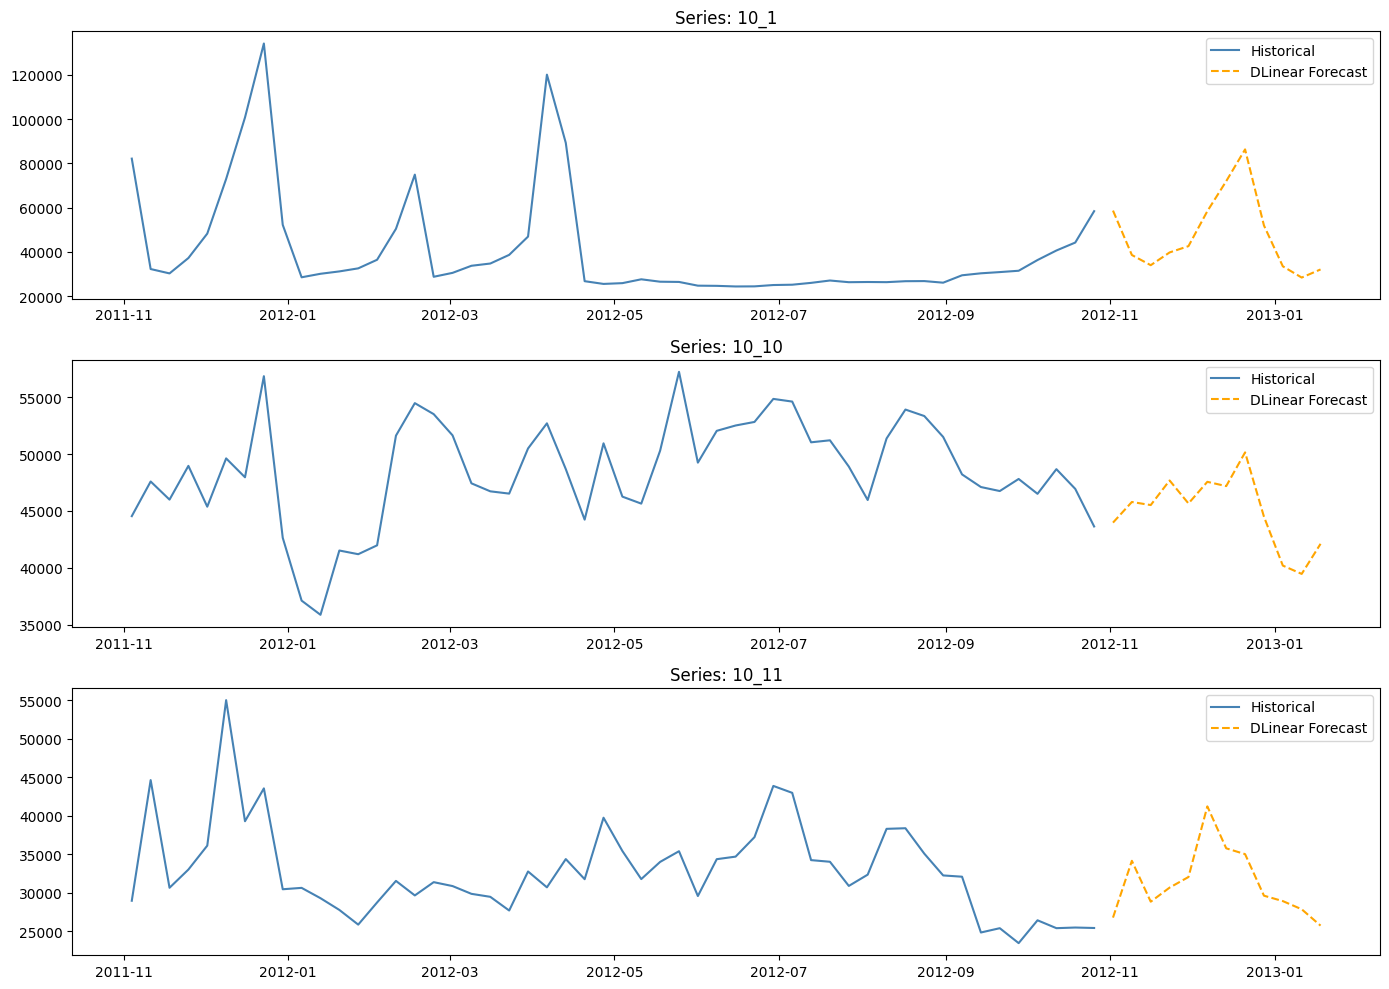

In [ ]:
sample_ids = forecasts_final['unique_id'].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, uid in zip(axes, sample_ids):
    hist = train_full_filtered[train_full_filtered['unique_id'] == uid].tail(52)
    fc = forecasts_final[forecasts_final['unique_id'] == uid]

    ax.plot(hist['ds'], hist['y'], label='Historical', color='steelblue')
    ax.plot(fc['ds'], fc['DLinear'], label='DLinear Forecast', color='orange', linestyle='--')
    ax.set_title(f'Series: {uid}')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. შეჯამება

WandB-ში მონიტორინგით გამოვცადეთ DLinear-ის სამი კონფიგურაცია:

| Run | კონფიგურაცია |
|---|---|
| **Baseline** | `moving_avg_window=25`, 500 ბიჯი |
| **Longer Window** | `moving_avg_window=51` — 1-წლიანი გადაგლუვება |
| **Longer Training** | 1500 ბიჯი, `LR=5e-4` |

საუკეთესო შედეგი: **Longer Training** — ვალიდაციის WMAE: **1494.80**.  
1-წლიანი smoothing ფანჯარა და უფრო ხანგრძლივი წვრთნა მოდელს ერთდროულად ეხმარება.

საბოლოო მოდელი გაიწვრთნა **3000 ბიჯით** სრულ სასწავლო ნაკრებზე (2934 დროითი მწკრივი) და შენახულია Drive-ზე `.pickle` ფაილად და WandB Artifact-ად.

---

### DLinear-ის ცენტრალური ჰიპოთეზის ტესტი

| მოდელი | ვალიდაციის WMAE | არქიტექტურის სირთულე |
|---|---|---|
| N-BEATS | 1378.04 | რთული — residual basis expansion |
| PatchTST | 1420.44 | ძალიან რთული — Transformer + patching |
| **DLinear** | **1494.80** | ძალიან მარტივი — მხოლოდ 2 Linear ფენა |

DLinear აჩვენებს, რომ Walmart-ის მონაცემებზე მარტივი წრფივი დეკომპოზიცია თითქმის იმავე შედეგს იძლევა, რასაც კომპლექსური Deep Learning არქიტექტურა. PatchTST-თან სხვაობა 5%-ზე ნაკლებია, თუმცა DLinear 3–4-ჯერ უფრო სწრაფად იწვრთნება.

---

### დასკვნა

ეს 2022 წლის ნაშრომის თეზისის ნათელი დადასტურებაა:

> *"Are Transformers Effective for Time Series Forecasting?"* — მოკლე პასუხი: **არა ყოველთვის.**